In [149]:
import pandas as pd

events = pd.read_csv("data/events1.csv")
items = pd.read_csv("data/items.csv")
users = pd.read_csv("data/users.csv")

print(events.shape)
print(items.shape)
print(users.shape)

(758884, 7)
(1381, 6)
(270154, 3)


In [150]:
events.head()

,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29


In [151]:
events["type"].value_counts()

type
add_to_cart       667282
begin_checkout     76047
purchase           15555
Name: count, dtype: int64

In [152]:
items.head()

,id,name,brand,variant,category,price_in_usd
0,0,Google Land & Sea Cotton Cap,Google,Single Option Only,Apparel,14
1,1,Google KeepCup,Google,Single Option Only,New,28
2,2,Google Land & Sea Nalgene Water Bottle,Google,Single Option Only,Drinkware,20
3,3,Google Unisex Eco Tee Black,Google,LG,Uncategorized Items,22
4,4,Google Chicago Campus Bottle,Google,Single Option Only,Campus Collection,11


In [153]:
users.head()

,id,ltv,date
0,0,0,2020-10-13 05:08:47
1,1,0,2020-11-24 14:26:54
2,2,0,2020-11-24 06:19:54
3,3,231,2020-05-02 11:09:15
4,4,102,2020-11-18 15:54:38


In [154]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 758884 entries, 0 to 758883
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user_id        758884 non-null  int64
 1   ga_session_id  758884 non-null  int64
 2   country        754329 non-null  str  
 3   device         758884 non-null  str  
 4   type           758884 non-null  str  
 5   item_id        758884 non-null  int64
 6   date           758884 non-null  str  
dtypes: int64(3), str(4)
memory usage: 40.5 MB


In [155]:
events["date"] = pd.to_datetime(events["date"])

events.info()

<class 'pandas.DataFrame'>
RangeIndex: 758884 entries, 0 to 758883
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        758884 non-null  int64         
 1   ga_session_id  758884 non-null  int64         
 2   country        754329 non-null  str           
 3   device         758884 non-null  str           
 4   type           758884 non-null  str           
 5   item_id        758884 non-null  int64         
 6   date           758884 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 40.5 MB


In [156]:
events.isnull().sum()

user_id             0
ga_session_id       0
country          4555
device              0
type                0
item_id             0
date                0
dtype: int64

In [157]:
events["country"] = events["country"].fillna("Unknown")

events.isnull().sum()

user_id          0
ga_session_id    0
country          0
device           0
type             0
item_id          0
date             0
dtype: int64

In [158]:
events.duplicated().sum()

np.int64(39498)

In [159]:
events = events.drop_duplicates()

events.duplicated().sum()

np.int64(0)

In [160]:
events["item_id"].isin(items["id"]).all()

np.True_

In [161]:
events["user_id"].isin(users["id"]).all()

np.True_

In [162]:
events[["user_id", "ga_session_id"]].nunique()

user_id          14701
ga_session_id    18034
dtype: int64

In [163]:
events['type'].nunique()

3

In [164]:
cart_users = events[events['type'] == 'add_to_cart']['user_id'].nunique()

In [165]:
checkout_users = events[events['type'] == 'begin_checkout']['user_id'].nunique()

In [166]:
purchase_users = events[events['type'] == 'purchase']['user_id'].nunique()

In [167]:
checkout_rate = round(checkout_users * 100 / cart_users, 2)
checkout_rate

51.05

In [168]:
purchase_conversion_rate = round(purchase_users * 100 / checkout_users, 2)
purchase_conversion_rate

63.49

In [169]:
stages = ["Add to Cart", "Begin Checkout", "Purchase"]

values = [12545, 6404, 4066]

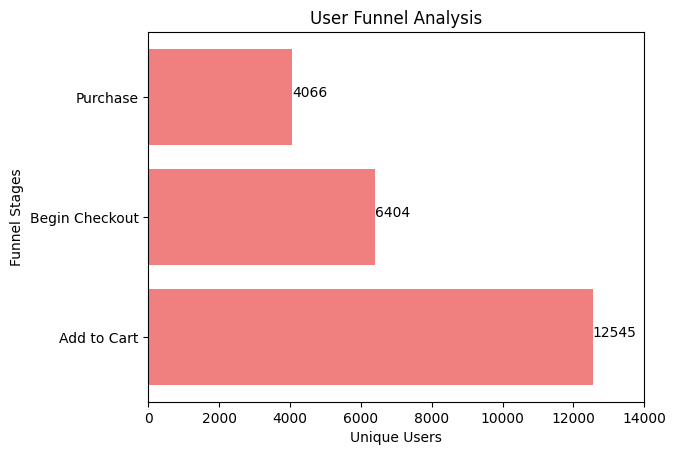

In [170]:
import matplotlib.pyplot as plt

# Funnel stages
stages = ["Add to Cart", "Begin Checkout", "Purchase"]

# Unique user counts
values = [12545, 6404, 4066]

# Create horizontal bar chart
plt.barh(stages, values, color='lightcoral')

# Add chart title and axis labels
plt.title("User Funnel Analysis")
plt.xlabel("Unique Users")
plt.ylabel("Funnel Stages")

# Add data labels on bars
for index, value in enumerate(values):
    plt.text(value, index, str(value))

plt.xlim(0, 14000)

# Display chart
plt.show()

In [171]:
event_products = pd.merge(
    events,
    items,
    left_on="item_id",
    right_on="id",
    how="left"
)

In [172]:
event_products.head()

,user_id,ga_session_id,country,device,type,item_id,date,id,name,brand,variant,category,price_in_usd
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,94,Google Large Tote White,Google,Single Option Only,Bags,10
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,425,Google Heather Green Speckled Tee,Google,XL,Apparel,21
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,1,Google KeepCup,Google,Single Option Only,New,28
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,62,Google Mini Kick Ball,Google,Single Option Only,Fun,2
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29,842,Google Infant Hero Onesie Grey,Google,NaN,Apparel,25


In [173]:
event_products['category'].value_counts()

category
Apparel                    282871
New                         70360
Accessories                 65098
Shop by Brand               47725
Campus Collection           45724
Clearance                   36529
Lifestyle                   27752
Bags                        26720
Office                      26291
Drinkware                   24387
Uncategorized Items         22026
Notebooks & Journals        16668
Stationery                   7122
Writing Instruments          6196
Google                       4996
Small Goods                  4942
Electronics Accessories      2102
Fun                          1113
Eco-Friendly                  495
Gift Cards                    254
Black Lives Matter             15
Name: count, dtype: int64

In [174]:
purchase_category_users = event_products[event_products['type'] == 'purchase'].groupby('category')['user_id'].nunique().sort_values(ascending=False)
purchase_category_users

category
Apparel                    2483
New                         903
Accessories                 759
Campus Collection           744
Shop by Brand               645
Office                      553
Drinkware                   537
Bags                        490
Clearance                   484
Lifestyle                   463
Uncategorized Items         340
Small Goods                 256
Stationery                  190
Google                      187
Writing Instruments         133
Electronics Accessories      41
Fun                          36
Notebooks & Journals         30
Eco-Friendly                 13
Gift Cards                   10
Black Lives Matter            2
Name: user_id, dtype: int64

In [175]:
cart_category_users = event_products[event_products['type'] == 'add_to_cart'].groupby('category')['user_id'].nunique().sort_values(ascending=False)
cart_category_users

category
Apparel                    10096
New                         7762
Clearance                   6316
Shop by Brand               5920
Lifestyle                   5320
Accessories                 5200
Uncategorized Items         3892
Drinkware                   3817
Bags                        3087
Office                      2889
Notebooks & Journals        2381
Campus Collection           1887
Stationery                  1481
Small Goods                 1476
Google                      1463
Writing Instruments          836
Electronics Accessories      780
Fun                          418
Eco-Friendly                 270
Gift Cards                    12
Black Lives Matter             3
Name: user_id, dtype: int64

In [176]:
category_conversion = round(
    purchase_category_users * 100 / cart_category_users,
    2
)

category_conversion.sort_values(ascending=False)

category
Gift Cards                 83.33
Black Lives Matter         66.67
Campus Collection          39.43
Apparel                    24.59
Office                     19.14
Small Goods                17.34
Writing Instruments        15.91
Bags                       15.87
Accessories                14.60
Drinkware                  14.07
Stationery                 12.83
Google                     12.78
New                        11.63
Shop by Brand              10.90
Uncategorized Items         8.74
Lifestyle                   8.70
Fun                         8.61
Clearance                   7.66
Electronics Accessories     5.26
Eco-Friendly                4.81
Notebooks & Journals        1.26
Name: user_id, dtype: float64

In [177]:
checkout_category_users = event_products[event_products['type'] == 'begin_checkout'].groupby('category')['user_id'].nunique().sort_values(ascending=False)
checkout_category_users

category
Apparel                    3863
New                        1165
Accessories                 922
Shop by Brand               879
Campus Collection           809
Bags                        701
Office                      686
Clearance                   629
Drinkware                   572
Lifestyle                   564
Uncategorized Items         334
Small Goods                 275
Google                      243
Stationery                  211
Writing Instruments         161
Electronics Accessories      54
Notebooks & Journals         43
Fun                          26
Eco-Friendly                 17
Gift Cards                   16
Black Lives Matter            1
Name: user_id, dtype: int64

In [178]:
funnel_summary = pd.concat(
    [cart_category_users,
     checkout_category_users,
     purchase_category_users],
    axis=1
)

funnel_summary.columns = [
    "cart_users",
    "checkout_users",
    "purchase_users"
]

funnel_summary

,cart_users,checkout_users,purchase_users
category,,,
Apparel,10096,3863,2483
New,7762,1165,903
Clearance,6316,629,484
Shop by Brand,5920,879,645
Lifestyle,5320,564,463
Accessories,5200,922,759
Uncategorized Items,3892,334,340
Drinkware,3817,572,537
Bags,3087,701,490


In [179]:
funnel_summary['checkout_conversion'] = round(funnel_summary['checkout_users'] * 100 / funnel_summary['cart_users'], 2)
funnel_summary['purchase_conversion'] = round(funnel_summary['purchase_users'] * 100 / funnel_summary['checkout_users'], 2)

In [180]:
filtered_funnel = funnel_summary[funnel_summary['cart_users'] > 100]

In [181]:
filtered_funnel.sort_values(
    by="purchase_conversion",
    ascending=False
)

,cart_users,checkout_users,purchase_users,checkout_conversion,purchase_conversion
category,,,,,
Fun,418,26,36,6.22,138.46
Uncategorized Items,3892,334,340,8.58,101.80
Drinkware,3817,572,537,14.99,93.88
Small Goods,1476,275,256,18.63,93.09
Campus Collection,1887,809,744,42.87,91.97
Stationery,1481,211,190,14.25,90.05
Writing Instruments,836,161,133,19.26,82.61
Accessories,5200,922,759,17.73,82.32
Lifestyle,5320,564,463,10.60,82.09


In [182]:
strict_funnel = filtered_funnel[
    ~filtered_funnel.index.isin(
        ["Fun", "Uncategorized Items"]
    )
]
strict_funnel.sort_values(
    by="checkout_conversion",
    ascending=False
)

,cart_users,checkout_users,purchase_users,checkout_conversion,purchase_conversion
category,,,,,
Campus Collection,1887,809,744,42.87,91.97
Apparel,10096,3863,2483,38.26,64.28
Office,2889,686,553,23.75,80.61
Bags,3087,701,490,22.71,69.90
Writing Instruments,836,161,133,19.26,82.61
Small Goods,1476,275,256,18.63,93.09
Accessories,5200,922,759,17.73,82.32
Google,1463,243,187,16.61,76.95
New,7762,1165,903,15.01,77.51


In [183]:
revenue = event_products[event_products['type'] == 'purchase'].groupby('category')['price_in_usd'].sum().sort_values(ascending=False)


In [184]:
revenue_per_purchasing_user = round(
    revenue / purchase_category_users,
    2
)

revenue_per_purchasing_user.sort_values(ascending=False)

category
Apparel                    63.32
Black Lives Matter         52.00
Gift Cards                 47.50
Bags                       39.06
Uncategorized Items        30.45
Shop by Brand              23.33
Lifestyle                  21.67
Campus Collection          20.90
New                        20.49
Drinkware                  19.56
Eco-Friendly               19.00
Accessories                18.19
Clearance                  17.78
Electronics Accessories    11.71
Small Goods                 9.34
Notebooks & Journals        8.20
Office                      8.14
Google                      4.82
Writing Instruments         3.85
Stationery                  3.65
Fun                         2.00
dtype: float64

In [185]:
filtered_revenue_per_user = revenue_per_purchasing_user[
    purchase_category_users >= 50
]

filtered_revenue_per_user.sort_values(ascending=False)

category
Apparel                63.32
Bags                   39.06
Uncategorized Items    30.45
Shop by Brand          23.33
Lifestyle              21.67
Campus Collection      20.90
New                    20.49
Drinkware              19.56
Accessories            18.19
Clearance              17.78
Small Goods             9.34
Office                  8.14
Google                  4.82
Writing Instruments     3.85
Stationery              3.65
dtype: float64

In [186]:
unique_users_by_device = event_products.groupby("device")["user_id"].nunique()
unique_users_by_device

device
desktop    8680
mobile     6026
tablet      327
Name: user_id, dtype: int64

In [187]:
unique_cart_users_by_device = event_products[event_products['type'] == 'add_to_cart'].groupby("device")["user_id"].nunique()
unique_cart_users_by_device

device
desktop    7384
mobile     5142
tablet      276
Name: user_id, dtype: int64

In [188]:
unique_checkout_users_by_device = event_products[event_products['type'] == 'begin_checkout'].groupby("device")["user_id"].nunique()
unique_checkout_users_by_device

device
desktop    3768
mobile     2568
tablet      146
Name: user_id, dtype: int64

In [189]:
unique_purchase_users_by_device = event_products[event_products['type'] == 'purchase'].groupby("device")["user_id"].nunique()
unique_purchase_users_by_device

device
desktop    2352
mobile     1688
tablet       85
Name: user_id, dtype: int64

In [190]:
device_funnel_summary = pd.concat(
    [unique_cart_users_by_device,
     unique_checkout_users_by_device,
     unique_purchase_users_by_device],
    keys=['Cart', 'Checkout', 'Purchase'],
    axis=1
)
device_funnel_summary

,Cart,Checkout,Purchase
device,,,
desktop,7384,3768,2352
mobile,5142,2568,1688
tablet,276,146,85


In [191]:
device_funnel_summary['Checkout Conversion'] = round(
    device_funnel_summary['Checkout'] * 100 / device_funnel_summary['Cart'], 2
)

device_funnel_summary['Purchase Conversion'] = round(
    device_funnel_summary['Purchase'] * 100 / device_funnel_summary['Checkout'],2
)

device_funnel_summary

,Cart,Checkout,Purchase,Checkout Conversion,Purchase Conversion
device,,,,,
desktop,7384,3768,2352,51.03,62.42
mobile,5142,2568,1688,49.94,65.73
tablet,276,146,85,52.90,58.22


In [192]:
event_products['date'].min(), event_products['date'].max()

(Timestamp('2020-11-01 00:27:14'), Timestamp('2021-01-31 23:59:08'))

In [193]:
event_products['filter_date'] = event_products['date'].dt.date
event_products.head()

,user_id,ga_session_id,country,device,type,item_id,date,id,name,brand,variant,category,price_in_usd,filter_date
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,94,Google Large Tote White,Google,Single Option Only,Bags,10,2020-11-01
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,425,Google Heather Green Speckled Tee,Google,XL,Apparel,21,2020-11-01
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,1,Google KeepCup,Google,Single Option Only,New,28,2020-11-01
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,62,Google Mini Kick Ball,Google,Single Option Only,Fun,2,2020-11-01
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29,842,Google Infant Hero Onesie Grey,Google,NaN,Apparel,25,2020-11-01


In [194]:
daily_event_volume = event_products.groupby(['filter_date', 'type'])['user_id'].nunique().unstack().fillna(0)
daily_event_volume

type,add_to_cart,begin_checkout,purchase
filter_date,,,
2020-11-01,1.0,0.0,13.0
2020-11-02,0.0,0.0,39.0
2020-11-03,0.0,0.0,46.0
2020-11-04,0.0,0.0,30.0
2020-11-05,0.0,0.0,26.0
...,...,...,...
2021-01-27,222.0,37.0,12.0
2021-01-28,179.0,18.0,5.0
2021-01-29,154.0,20.0,6.0


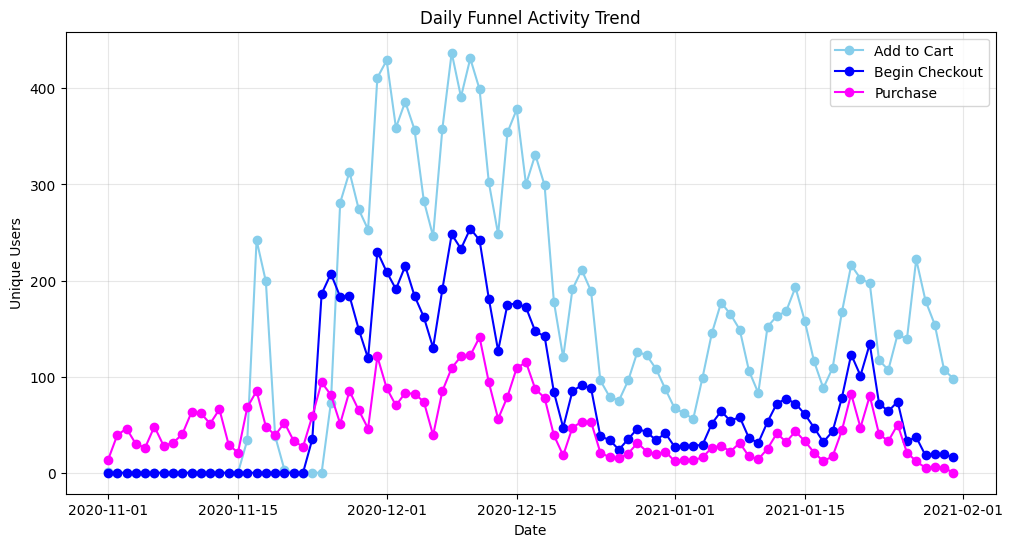

In [195]:
plt.figure(figsize=(12, 6))
plt.plot(daily_event_volume.index, daily_event_volume['add_to_cart'], label='Add to Cart', marker='o', color='skyblue')
plt.legend()

plt.plot(daily_event_volume.index, daily_event_volume['begin_checkout'], label='Begin Checkout', marker='o', color='blue')
plt.legend()
plt.plot(daily_event_volume.index, daily_event_volume['purchase'], label='Purchase', marker='o', color='magenta')
plt.legend()
plt.title('Daily Funnel Activity Trend')

plt.xlabel('Date')

plt.ylabel('Unique Users')

plt.grid(alpha=0.3)

plt.show()


Chart Summary - 
The funnel exhibited strong seasonal activity during the holiday period, with cart activity peaking significantly in December. The largest user drop-off consistently occurred between add-to-cart and checkout initiation, suggesting friction before purchase intent solidifies. Purchase trends broadly followed engagement patterns, indicating healthy downstream conversion once users entered checkout.